# **Loading The Data**

In [ ]:
%pip install mlcroissant

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.4/155.4 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 3.6 MB/s eta 0:00:00
  Created wheel for jsonpath-rw: filename=jsonpath_rw-1.4.0-py3-none-any.whl size=15127 sha256=38bae873d110ac325fecb3d763f2f6c548e3c45a693abcc6b6cd6e9b19520384
  Stored in directory: /root/.cache/pip/wheels/e5/8d/50/ee73263c97069bd6040ff40633d444fefaac7beff73abe81a7
Successfully built jsonpath-rw


In [ ]:
# ── Standard Library ───────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import mlcroissant as mlc
warnings.filterwarnings('ignore')

# ── Sklearn: Preprocessing & Model Selection ───────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.model_selection import StratifiedKFold, cross_validate

# ── Sklearn: Models ────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# ── XGBoost ────────────────────────────────────────────────────
from xgboost import XGBClassifier

# ── Neural Network ─────────────────────────────────────────────
from sklearn.neural_network import MLPClassifier

# ── Imbalanced Learn (optional) ────────────────────────────────
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [ ]:
# Fetch the Croissant JSON-LD
croissant_dataset = mlc.Dataset('https://www.kaggle.com/datasets/utkarshx27/american-companies-bankruptcy-prediction-dataset/croissant/download')

# Check what record sets are in the dataset
record_sets = croissant_dataset.metadata.record_sets
print(record_sets)

# Fetch the records and put them in a DataFrame
df = pd.DataFrame(croissant_dataset.records(record_set=record_sets[0].uuid))
df.head()


  -  [Metadata(US Company Bankruptcy Prediction Dataset)] Property "http://mlcommons.org/croissant/citeAs" is recommended, but does not exist.


[RecordSet(uuid="american_bankruptcy.csv")]


,american_bankruptcy.csv/company_name,american_bankruptcy.csv/status_label,american_bankruptcy.csv/year,american_bankruptcy.csv/X1,american_bankruptcy.csv/X2,american_bankruptcy.csv/X3,american_bankruptcy.csv/X4,american_bankruptcy.csv/X5,american_bankruptcy.csv/X6,american_bankruptcy.csv/X7,...,american_bankruptcy.csv/X9,american_bankruptcy.csv/X10,american_bankruptcy.csv/X11,american_bankruptcy.csv/X12,american_bankruptcy.csv/X13,american_bankruptcy.csv/X14,american_bankruptcy.csv/X15,american_bankruptcy.csv/X16,american_bankruptcy.csv/X17,american_bankruptcy.csv/X18
0,b'C_1',b'alive',1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,...,1024.333,740.998,180.447,70.658,191.226,163.816,201.026,1024.333,401.483,935.302
1,b'C_1',b'alive',2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,...,874.255,701.854,179.987,45.790,160.444,125.392,204.065,874.255,361.642,809.888
2,b'C_1',b'alive',2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,...,638.721,710.199,217.699,4.711,112.244,150.464,139.603,638.721,399.964,611.514
3,b'C_1',b'alive',2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,...,606.337,686.621,164.658,3.573,109.590,203.575,124.106,606.337,391.633,575.592
4,b'C_1',b'alive',2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,...,651.958,709.292,248.666,20.811,128.656,131.261,131.884,651.958,407.608,604.467


In [ ]:
# remove the 'american_bankruptcy.csv/' prefix on the column names
df.columns = df.columns.str.replace('american_bankruptcy.csv/', '')
display(df.head())

,company_name,status_label,year,X1,X2,X3,X4,X5,X6,X7,...,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18
0,b'C_1',b'alive',1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,...,1024.333,740.998,180.447,70.658,191.226,163.816,201.026,1024.333,401.483,935.302
1,b'C_1',b'alive',2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,...,874.255,701.854,179.987,45.790,160.444,125.392,204.065,874.255,361.642,809.888
2,b'C_1',b'alive',2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,...,638.721,710.199,217.699,4.711,112.244,150.464,139.603,638.721,399.964,611.514
3,b'C_1',b'alive',2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,...,606.337,686.621,164.658,3.573,109.590,203.575,124.106,606.337,391.633,575.592
4,b'C_1',b'alive',2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,...,651.958,709.292,248.666,20.811,128.656,131.261,131.884,651.958,407.608,604.467


# **Data Description**

### **Unit of Analysis**
Each unique observation consists of a company and the corresponding reporting year.

### **Features**

- **company_name**
- **status_label -** Company Status (Target Column)
- **year**
- **X1: Current assets -** All the assets of a company that are expected to be sold or used as a result of standard business
- **X2: Cost of goods sold -** The total amount a company paid as a cost directly related to the sale of products
- **X3: Depreciation and amortization -** Depreciation refers to the loss of value of a tangible fixed asset oveR
- **X4: EBITDA -** Earnings before interest, taxes, depreciation, and amortization. A measure of a company’s overall
- **X5: Inventory -** The accounting of items and raw materials that a company either uses in production or sells
- **X6: Net Income -** The overall profitability of a company after all expenses and costs have been deducted from total revenue
- **X7: Total Receivables -** The balance of money due to a firm for goods or services delivered or used but not yet paid for
- **X8: Market Value -** The price of an asset in a marketplace. In our dataset, it refers to the market capitalization
- **X9: Net Sales -** The sum of a company’s gross sales minus its returns, allowances, and discounts
- **X10: Total Assets -** All the assets, or items of value, a business owns
- **X11: Total Long-term Debt -** A company’s loans and other liabilities that will not become due within one year of the balance
- **X12: EBIT -** Earnings before interest and taxes
- **X13: Gross Profit -** The profit a business makes after subtracting all the costs that are related to manufacturing and selling its products or services
- **X14: Total Current Liabilities -** The sum of accounts payable, accrued liabilities, and taxes such as bonds payable at the end of the year, salaries, and commissions remaining
- **X15: Retained Earnings -** The amount of profit a company has left over after paying all its direct costs, indirect costs, income taxes, and dividends to shareholders
- **X16: Total Revenue -** The amount of income that a business has made from all sales before subtracting expenses. It may include interest and dividends from investments
- **X17: Total Liabilities -** The combined debts and obligations that the company owes to outside parties
- **X18: Total Operating Expenses -** The expense a business incurs through its normal business operations

In [ ]:
# rename the columns so we dont have to keep referring to the column dictionary above
column_mapping = {
    'X1': 'current_assets',
    'X2': 'cost_of_goods_sold',
    'X3': 'depreciation_amortization',
    'X4': 'ebitda',
    'X5': 'inventory',
    'X6': 'net_income',
    'X7': 'total_receivables',
    'X8': 'market_value',
    'X9': 'net_sales',
    'X10': 'total_assets',
    'X11': 'total_longterm_debt',
    'X12': 'ebit',
    'X13': 'gross_profit',
    'X14': 'total_current_liabilities',
    'X15': 'retained_earnings',
    'X16': 'total_revenue',
    'X17': 'total_liabilities',
    'X18': 'total_operating_expenses'
}

df = df.rename(columns=column_mapping)
df.head()

,company_name,status_label,year,current_assets,cost_of_goods_sold,depreciation_amortization,ebitda,inventory,net_income,total_receivables,...,net_sales,total_assets,total_longterm_debt,ebit,gross_profit,total_current_liabilities,retained_earnings,total_revenue,total_liabilities,total_operating_expenses
0,b'C_1',b'alive',1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,...,1024.333,740.998,180.447,70.658,191.226,163.816,201.026,1024.333,401.483,935.302
1,b'C_1',b'alive',2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,...,874.255,701.854,179.987,45.790,160.444,125.392,204.065,874.255,361.642,809.888
2,b'C_1',b'alive',2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,...,638.721,710.199,217.699,4.711,112.244,150.464,139.603,638.721,399.964,611.514
3,b'C_1',b'alive',2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,...,606.337,686.621,164.658,3.573,109.590,203.575,124.106,606.337,391.633,575.592
4,b'C_1',b'alive',2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,...,651.958,709.292,248.666,20.811,128.656,131.261,131.884,651.958,407.608,604.467


### **Checking for Missing Values**

In [ ]:
# check columns for missing values - there are no missing values in any of the columns
print(df.isnull().sum())

company_name                 0
status_label                 0
year                         0
current_assets               0
cost_of_goods_sold           0
depreciation_amortization    0
ebitda                       0
inventory                    0
net_income                   0
total_receivables            0
market_value                 0
net_sales                    0
total_assets                 0
total_longterm_debt          0
ebit                         0
gross_profit                 0
total_current_liabilities    0
retained_earnings            0
total_revenue                0
total_liabilities            0
total_operating_expenses     0
dtype: int64


### **Checking for Extreme Values**

In [ ]:
# check columns for extreme values
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,78682.0,2007.506317,5.742768,1999.0000,2002.00000,2007.00000,2012.00000,2018.00
current_assets,78682.0,880.362485,3928.564794,-7.7600,18.92400,100.44950,431.52675,169662.00
cost_of_goods_sold,78682.0,1594.529029,8930.484664,-366.6450,17.03825,103.66100,634.54800,374623.00
depreciation_amortization,78682.0,121.234256,652.376804,0.0000,1.19200,7.92950,47.97175,28430.00
ebitda,78682.0,376.759424,2012.023142,-21913.0000,-0.81100,15.03450,139.65525,81730.00
inventory,78682.0,201.605717,1060.766096,0.0000,0.00000,7.02300,74.74725,62567.00
net_income,78682.0,129.382453,1265.532022,-98696.0000,-7.41575,1.61600,40.14425,104821.00
total_receivables,78682.0,286.832743,1335.978571,-0.0060,3.28125,22.82000,131.58050,65812.00
market_value,78682.0,3414.354610,18414.103647,0.0001,34.98000,227.51185,1244.88995,1073390.54
net_sales,78682.0,2364.019706,11950.068842,-1964.9990,27.54850,186.59850,1046.40250,511729.00


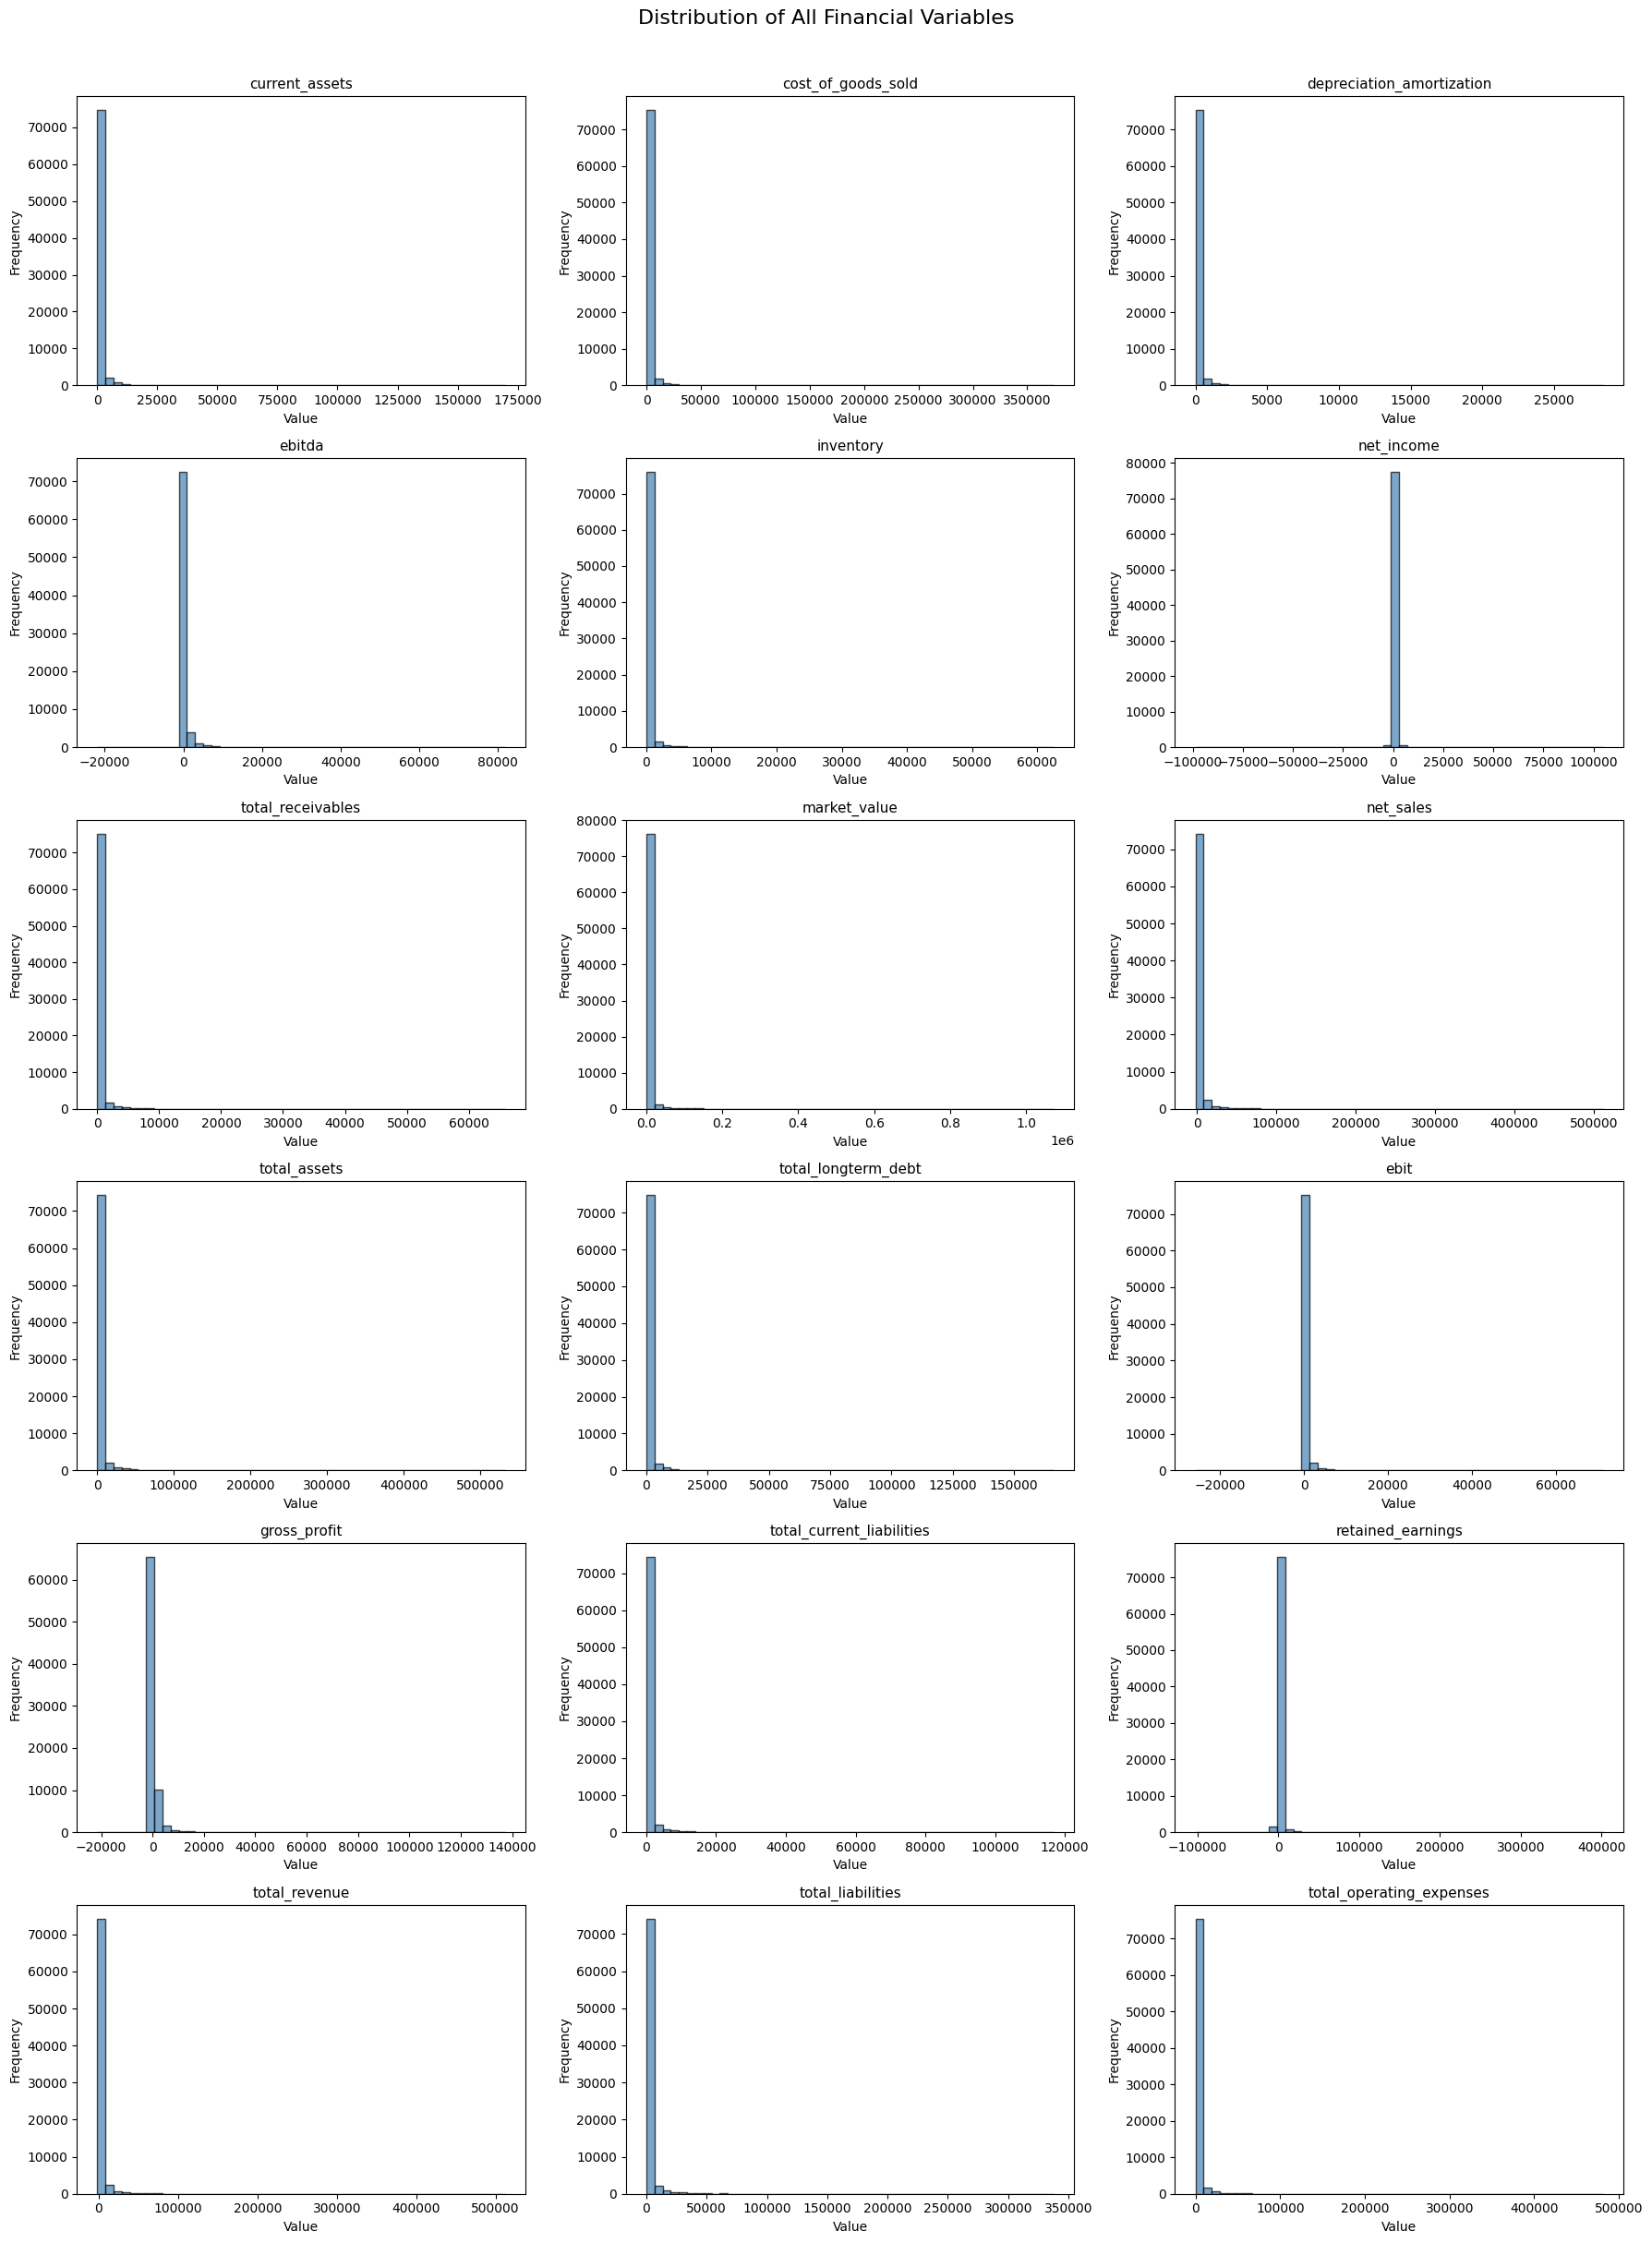

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

numeric_cols = df.select_dtypes(include='number').drop(columns=['year'])

fig, axes = plt.subplots(6, 3, figsize=(18, 24))
axes = axes.flatten()

for i, col in enumerate(numeric_cols.columns):
    axes[i].hist(df[col], bins=50, edgecolor='black', color='steelblue', alpha=0.7)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

plt.suptitle('Distribution of All Financial Variables', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

### **Checking Other Data Features**

In [ ]:
# 1. Firm-year observations
print("=== FIRM-YEAR OBSERVATIONS ===")
print("Total firm-year obs:", len(df))
print("Unique firms:", df['company_name'].nunique())
print("Year range:", df['year'].min(), "to", df['year'].max())
print("Unique years:", df['year'].nunique())

# 2. Bankrupt observations
print("\n=== BANKRUPTCY COUNTS ===")
print(df['status_label'].value_counts())
print(df['status_label'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

# 3. Bankruptcy rate by sample period
print("\n=== BANKRUPTCY RATE BY PERIOD ===")
def get_period(year):
    if year <= 2011:
        return 'Train (1999-2011)'
    elif year <= 2014:
        return 'Validation (2012-2014)'
    else:
        return 'Test (2015-2018)'

df['period'] = df['year'].apply(get_period)
period_stats = df.groupby('period')['status_label'].apply(
    lambda x: f"{(x == b'failed').sum() / len(x) * 100:.2f}%"
)
print(period_stats)

=== FIRM-YEAR OBSERVATIONS ===
Total firm-year obs: 78682
Unique firms: 8971
Year range: 1999 to 2018
Unique years: 20

=== BANKRUPTCY COUNTS ===
status_label
b'alive'     73462
b'failed'     5220
Name: count, dtype: int64
status_label
b'alive'     93.37%
b'failed'     6.63%
Name: proportion, dtype: object

=== BANKRUPTCY RATE BY PERIOD ===
period
Test (2015-2018)          2.34%
Train (1999-2011)         7.94%
Validation (2012-2014)    4.69%
Name: status_label, dtype: object


# **Feature Engineering**

In [ ]:
# Avoid division by zero by replacing 0s with NaN
df['current_ratio'] = df['current_assets'] / df['total_current_liabilities'].replace(0, float('nan'))
df['working_capital_to_assets'] = (df['current_assets'] - df['total_current_liabilities']) / df['total_assets'].replace(0, float('nan'))

# Profitability
df['roa'] = df['net_income'] / df['total_assets'].replace(0, float('nan'))
df['ebitda_margin'] = df['ebitda'] / df['total_revenue'].replace(0, float('nan'))
df['gross_margin'] = df['gross_profit'] / df['total_revenue'].replace(0, float('nan'))
df['ebit_margin'] = df['ebit'] / df['total_revenue'].replace(0, float('nan'))
df['retained_earnings_to_assets'] = df['retained_earnings'] / df['total_assets'].replace(0, float('nan'))

# Leverage
df['debt_ratio'] = df['total_liabilities'] / df['total_assets'].replace(0, float('nan'))
df['longterm_debt_to_assets'] = df['total_longterm_debt'] / df['total_assets'].replace(0, float('nan'))
df['debt_to_equity'] = df['total_liabilities'] / (df['total_assets'] - df['total_liabilities']).replace(0, float('nan'))

# Efficiency
df['asset_turnover'] = df['net_sales'] / df['total_assets'].replace(0, float('nan'))
df['inventory_turnover'] = df['cost_of_goods_sold'] / df['inventory'].replace(0, float('nan'))
df['receivables_turnover'] = df['net_sales'] / df['total_receivables'].replace(0, float('nan'))

# Market-based
df['market_to_liabilities'] = df['market_value'] / df['total_liabilities'].replace(0, float('nan'))
df['market_to_assets'] = df['market_value'] / df['total_assets'].replace(0, float('nan'))

# ALTMAN

df['altman_X1'] = (df['current_assets'] - df['total_current_liabilities']) / df['total_assets'].replace(0, float('nan'))
df['altman_X2'] = df['retained_earnings'] / df['total_assets'].replace(0, float('nan'))
df['altman_X3'] = df['ebit'] / df['total_assets'].replace(0, float('nan'))
df['altman_X4'] = df['market_value'] / df['total_liabilities'].replace(0, float('nan'))
df['altman_X5'] = df['net_sales'] / df['total_assets'].replace(0, float('nan'))

df['altman_z'] = (1.2 * df['altman_X1'] +
                  1.4 * df['altman_X2'] +
                  3.3 * df['altman_X3'] +
                  0.6 * df['altman_X4'] +
                  1.0 * df['altman_X5'])

print("New columns added:", df.shape[1], "total columns")
df.head()

New columns added: 43 total columns


,company_name,status_label,year,current_assets,cost_of_goods_sold,depreciation_amortization,ebitda,inventory,net_income,total_receivables,...,inventory_turnover,receivables_turnover,market_to_liabilities,market_to_assets,altman_X1,altman_X2,altman_X3,altman_X4,altman_X5,altman_z
0,b'C_1',b'alive',1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,...,2.479352,7.980903,0.928438,0.503040,0.468896,0.271291,0.095355,0.928438,1.382369,3.196587
1,b'C_1',b'alive',2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,...,2.226554,7.589876,1.042794,0.537317,0.513588,0.290751,0.065241,1.042794,1.245637,3.109968
2,b'C_1',b'alive',2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,...,1.837052,8.238585,0.911564,0.513367,0.402974,0.196569,0.006633,0.911564,0.899355,2.226949
3,b'C_1',b'alive',2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,...,1.910903,9.142321,0.365979,0.208746,0.280849,0.180749,0.005204,0.365979,0.883074,1.709901
4,b'C_1',b'alive',2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,...,2.116532,6.229235,0.757853,0.435515,0.424286,0.185938,0.029341,0.757853,0.919167,2.240159


In [ ]:
new_ratio_cols = ['current_ratio', 'working_capital_to_assets', 'roa', 'ebitda_margin',
                  'gross_margin', 'ebit_margin', 'retained_earnings_to_assets', 'debt_ratio',
                  'longterm_debt_to_assets', 'debt_to_equity', 'asset_turnover',
                  'inventory_turnover', 'receivables_turnover', 'market_to_liabilities', 'market_to_assets']

print(df[new_ratio_cols].isnull().sum())

current_ratio                      0
working_capital_to_assets          0
roa                                0
ebitda_margin                      0
gross_margin                       0
ebit_margin                        0
retained_earnings_to_assets        0
debt_ratio                         0
longterm_debt_to_assets            0
debt_to_equity                     2
asset_turnover                     0
inventory_turnover             19701
receivables_turnover            2205
market_to_liabilities              0
market_to_assets                   0
dtype: int64


In [ ]:
# we can either fill the null columns with 0 or median values - for now we fill with median values to avoid distortion
for col in new_ratio_cols:
    df[col] = df[col].fillna(df[col].median())

# **Modeling**

### **Splitting Data**

In [ ]:
# Y = 1 only for a failed firm's final observed year (predict t+1 default)
last_year = df.groupby('company_name')['year'].transform('max')
is_failed = df['status_label'].eq(b'failed')
df['bankrupt'] = (is_failed & df['year'].eq(last_year)).astype(int)

# TRAIN / VAL / TEST SPLIT
train = df[df['year'] <= 2011]
val   = df[(df['year'] >= 2012) & (df['year'] <= 2014)]
test  = df[df['year'] >= 2015]

# RAW FEATURE MATRICES
drop_cols = ['company_name', 'status_label', 'year', 'bankrupt']

X_train_raw = train.drop(columns=drop_cols)
y_train_raw = train['bankrupt']

X_val  = val.drop(columns=drop_cols)
y_val  = val['bankrupt']

X_test = test.drop(columns=drop_cols)
y_test = test['bankrupt']


# UNDERSAMPLE TRAINING SET ONLY (70/30)
# This is so that we even out the minority class with majority class without making fake data
rus = RandomUnderSampler(sampling_strategy=0.4286, random_state=42)
X_train, y_train = rus.fit_resample(X_train_raw, y_train_raw)

print("=== ORIGINAL TRAINING SET ===")
print(f"Total: {len(y_train_raw)} | Bankrupt: {y_train_raw.sum()} ({y_train_raw.mean()*100:.2f}%)")

print("\n=== RESAMPLED TRAINING SET (70/30) ===")
print(f"Total: {len(y_train)} | Bankrupt: {y_train.sum()} ({y_train.mean()*100:.2f}%)")

print("\n=== VALIDATION SET (unchanged) ===")
print(f"Total: {len(y_val)} | Bankrupt: {y_val.sum()} ({y_val.mean()*100:.2f}%)")

print("\n=== TEST SET (unchanged) ===")
print(f"Total: {len(y_test)} | Bankrupt: {y_test.sum()} ({y_test.mean()*100:.2f}%)")

=== ORIGINAL TRAINING SET ===
Total: 55927 | Bankrupt: 403 (0.72%)

=== RESAMPLED TRAINING SET (70/30) ===
Total: 1343 | Bankrupt: 403 (30.01%)

=== VALIDATION SET (unchanged) ===
Total: 10473 | Bankrupt: 87 (0.83%)

=== TEST SET (unchanged) ===
Total: 12282 | Bankrupt: 119 (0.97%)


### **Altman**

In [ ]:
altman_cols = ['altman_X1', 'altman_X2', 'altman_X3', 'altman_X4', 'altman_X5', 'altman_z', 'bankrupt']
altman_train = train[altman_cols]
altman_val = val[altman_cols]
altman_test = test[altman_cols]

In [ ]:
# mean z-score by status
print("=== AVERAGE Z-SCORE BY STATUS (Test Set) ===")
print(altman_test.groupby('bankrupt')[['altman_X1', 'altman_X2', 'altman_X3',
                                        'altman_X4', 'altman_X5', 'altman_z']]
      .mean().round(4).T.rename(columns={0: 'Alive', 1: 'Bankrupt'}))

=== AVERAGE Z-SCORE BY STATUS (Test Set) ===
bankrupt     Alive  Bankrupt
altman_X1  -1.1600   -7.0657
altman_X2 -14.1148  -44.9528
altman_X3  -0.6904   -1.7036
altman_X4  23.0224    1.2098
altman_X5   1.0371    0.9577
altman_z   -8.5806  -75.3512


In [ ]:
# auc scores
altman_roc = roc_auc_score(altman_test['bankrupt'], -altman_test['altman_z'])
altman_prauc = average_precision_score(altman_test['bankrupt'], -altman_test['altman_z'])

print(f"\nROC-AUC: {altman_roc:.4f}")
print(f"PR-AUC:  {altman_prauc:.4f}")


ROC-AUC: 0.7942
PR-AUC:  0.0264


In [ ]:
# confusion matrix
altman_test['altman_pred'] = (altman_test['altman_z'] < 1.81).astype(int)
cm = confusion_matrix(altman_test['bankrupt'], altman_test['altman_pred'])

TP = cm[1,1]; FP = cm[0,1]; FN = cm[1,0]; TN = cm[0,0]
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print("\n=== CONFUSION MATRIX (Z < 1.81 = Distress) ===")
print(f"                  Actual Distress   Actual Healthy")
print(f"Pred Distress     TP = {TP:<10}    FP = {FP}")
print(f"Pred Healthy      FN = {FN:<10}    TN = {TN}")
print(f"\nAccuracy:  {(TP+TN)/(TP+FP+FN+TN)*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall:    {recall*100:.2f}%")
print(f"F1 Score:  {f1*100:.2f}%")


=== CONFUSION MATRIX (Z < 1.81 = Distress) ===
                  Actual Distress   Actual Healthy
Pred Distress     TP = 105           FP = 4925
Pred Healthy      FN = 14            TN = 7238

Accuracy:  59.79%
Precision: 2.09%
Recall:    88.24%
F1 Score:  4.08%


In [ ]:
from sklearn.metrics import balanced_accuracy_score

balanced_acc = balanced_accuracy_score(altman_test['bankrupt'], altman_test['altman_pred'])
print(f"Balanced Accuracy: {balanced_acc*100:.2f}%")

Balanced Accuracy: 73.87%


In [ ]:
# risk buckets
altman_sorted = altman_test.sort_values('altman_z', ascending=True)
total_bankruptcies = altman_sorted['bankrupt'].sum()

print("\n=== TOP RISK BUCKET RECALL ===")
for pct in [0.05, 0.10]:
    n = int(len(altman_sorted) * pct)
    captured = altman_sorted.head(n)['bankrupt'].sum()
    recall_b = captured / total_bankruptcies * 100
    print(f"Top {int(pct*100)}% ({n} firms): {captured} captured = {recall_b:.1f}% of all bankruptcies")


=== TOP RISK BUCKET RECALL ===
Top 5% (614 firms): 13 captured = 10.9% of all bankruptcies
Top 10% (1228 firms): 31 captured = 26.1% of all bankruptcies


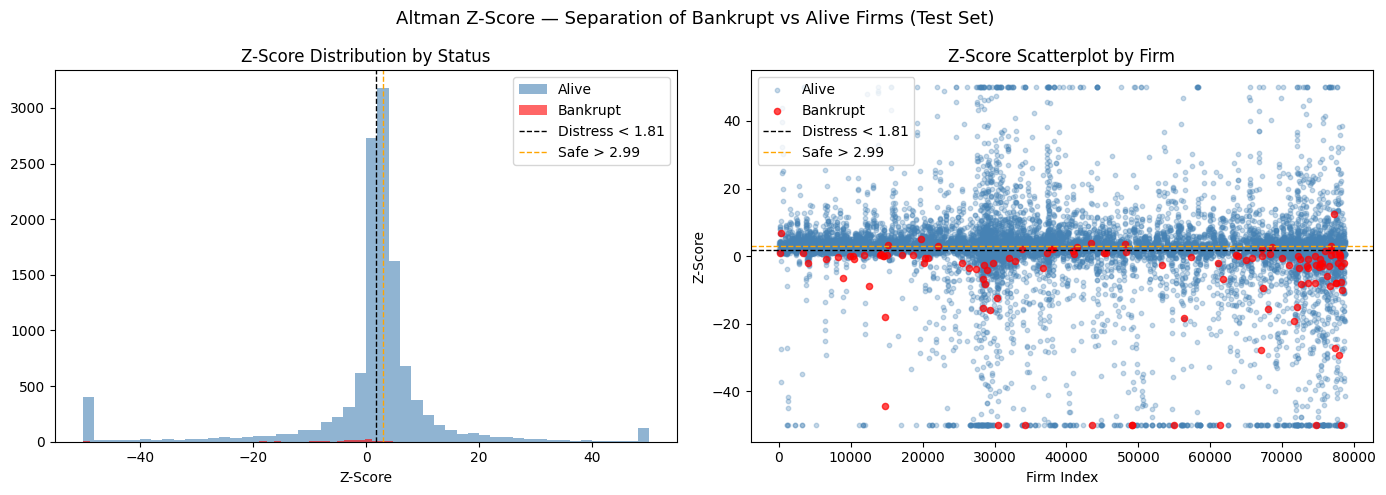

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram
axes[0].hist(altman_test[altman_test['bankrupt']==0]['altman_z'].clip(-50, 50),
             bins=50, alpha=0.6, label='Alive', color='steelblue')
axes[0].hist(altman_test[altman_test['bankrupt']==1]['altman_z'].clip(-50, 50),
             bins=50, alpha=0.6, label='Bankrupt', color='red')
axes[0].axvline(1.81, color='black',  linestyle='--', linewidth=1, label='Distress < 1.81')
axes[0].axvline(2.99, color='orange', linestyle='--', linewidth=1, label='Safe > 2.99')
axes[0].set_title('Z-Score Distribution by Status')
axes[0].set_xlabel('Z-Score')
axes[0].legend()

# scatterplot
axes[1].scatter(altman_test[altman_test['bankrupt']==0].index,
                altman_test[altman_test['bankrupt']==0]['altman_z'].clip(-50, 50),
                alpha=0.3, s=10, color='steelblue', label='Alive')
axes[1].scatter(altman_test[altman_test['bankrupt']==1].index,
                altman_test[altman_test['bankrupt']==1]['altman_z'].clip(-50, 50),
                alpha=0.7, s=20, color='red', label='Bankrupt')
axes[1].axhline(1.81, color='black',  linestyle='--', linewidth=1, label='Distress < 1.81')
axes[1].axhline(2.99, color='orange', linestyle='--', linewidth=1, label='Safe > 2.99')
axes[1].set_title('Z-Score Scatterplot by Firm')
axes[1].set_xlabel('Firm Index')
axes[1].set_ylabel('Z-Score')
axes[1].legend()

plt.suptitle('Altman Z-Score — Separation of Bankrupt vs Alive Firms (Test Set)', fontsize=13)
plt.tight_layout()
plt.show()

### **Altman With Optimized Weights & Threshold**


=== ORIGINAL VS OPTIMIZED WEIGHTS ===
Ratio        Original  Optimized
--------------------------------
altman_X1      1.2000     1.1858
altman_X2      1.4000    -0.1406
altman_X3      3.3000     6.7017
altman_X4      0.6000     0.3264
altman_X5      1.0000     0.0256

Best threshold on validation: -0.20 (F1=0.0767)

=== ALTMAN — TEST SET RESULTS ===
Metric         Original  Optimized
----------------------------------
ROC-AUC          0.7942     0.8353
PR-AUC           0.0264     0.0359
Precision        0.0209     0.0414
Recall           0.8824     0.6471
F1               0.0408     0.0778
Accuracy         0.5979     0.8514
Bal. Acc         0.7387     0.7502

=== TOP RISK BUCKET RECALL ===
Bucket         Original  Optimized
----------------------------------
Top 5%           10.9%      16.8%
Top 10%           26.1%      38.7%


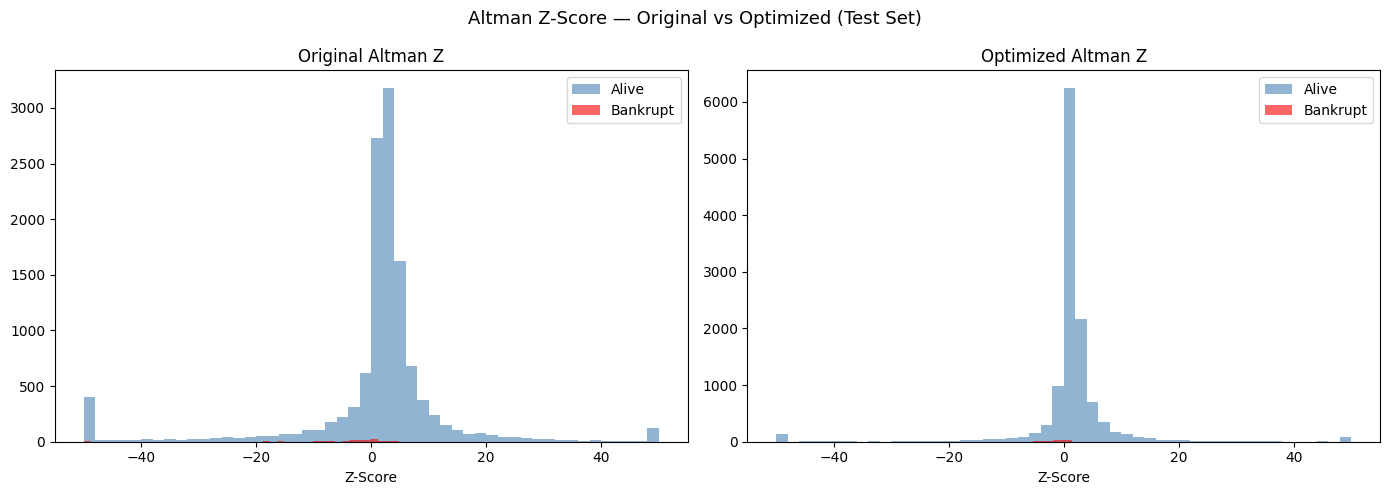

In [ ]:
# This section tries to adjust the weights and the threshold
# We use validation to optimize weights and threshold
# Then evaluate final metrics on test set only

from scipy.optimize import minimize
from sklearn.metrics import f1_score, accuracy_score


altman_cols = ['altman_X1', 'altman_X2', 'altman_X3', 'altman_X4', 'altman_X5']

# pull altman ratios from each split
X_train_altman = train[altman_cols].fillna(0)
X_val_altman   = val[altman_cols].fillna(0)
X_test_altman  = test[altman_cols].fillna(0)

y_train_altman = train['bankrupt']
y_val_altman   = val['bankrupt']
y_test_altman  = test['bankrupt']

# STEP 1: ORIGINAL ALTMAN WEIGHTS
w_original = np.array([1.2, 1.4, 3.3, 0.6, 1.0])

train['altman_z'] = X_train_altman.values @ w_original
val['altman_z'] = X_val_altman.values @ w_original
test['altman_z'] = X_test_altman.values  @ w_original

# STEP 2: OPTIMIZE WEIGHTS ON VALIDATION
def neg_roc(weights):
    z = X_val_altman.values @ weights
    return -roc_auc_score(y_val_altman, -z)

result = minimize(neg_roc, w_original, method='Nelder-Mead')
best_weights = result.x

print("=== ORIGINAL VS OPTIMIZED WEIGHTS ===")
print(f"{'Ratio':<10} {'Original':>10} {'Optimized':>10}")
print("-" * 32)
for name, orig, opt in zip(altman_cols, w_original, best_weights):
    print(f"{name:<10} {orig:>10.4f} {opt:>10.4f}")

# STEP 3: COMPUTE OPTIMIZED Z-SCORE
val['altman_z_opt']  = X_val_altman.values  @ best_weights
test['altman_z_opt'] = X_test_altman.values @ best_weights

# STEP 4: TUNE THRESHOLD ON VALIDATION
thresholds  = np.arange(-10, 10, 0.1)
best_thresh = 0
best_f1_val = 0

for t in thresholds:
    preds = (val['altman_z_opt'] < t).astype(int)
    f1    = f1_score(y_val_altman, preds, zero_division=0)
    if f1 > best_f1_val:
        best_f1_val = f1
        best_thresh = t

print(f"\nBest threshold on validation: {best_thresh:.2f} (F1={best_f1_val:.4f})")

# STEP 5: FINAL EVALUATION ON TEST
test['altman_pred_orig'] = (test['altman_z']     < 1.81).astype(int)
test['altman_pred_opt']  = (test['altman_z_opt'] < best_thresh).astype(int)

def get_metrics(y_true, y_pred, y_score):
    cm        = confusion_matrix(y_true, y_pred)
    TP = cm[1,1]; FP = cm[0,1]; FN = cm[1,0]; TN = cm[0,0]
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    return {
        'ROC-AUC':   roc_auc_score(y_true, y_score),
        'PR-AUC':    average_precision_score(y_true, y_score),
        'Precision': precision,
        'Recall':    recall,
        'F1':        f1,
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Bal. Acc':  balanced_accuracy_score(y_true, y_pred)
    }

orig_metrics = get_metrics(y_test_altman, test['altman_pred_orig'], -test['altman_z'])
opt_metrics  = get_metrics(y_test_altman, test['altman_pred_opt'],  -test['altman_z_opt'])

print("\n=== ALTMAN — TEST SET RESULTS ===")
print(f"{'Metric':<12} {'Original':>10} {'Optimized':>10}")
print("-" * 34)
for metric in orig_metrics:
    print(f"{metric:<12} {orig_metrics[metric]:>10.4f} {opt_metrics[metric]:>10.4f}")

# TOP RISK BUCKET
print("\n=== TOP RISK BUCKET RECALL ===")
print(f"{'Bucket':<12} {'Original':>10} {'Optimized':>10}")
print("-" * 34)

total = y_test_altman.sum()
for pct in [0.05, 0.10]:
    n         = int(len(test) * pct)
    orig_cap  = test.sort_values('altman_z',     ascending=True).head(n)['bankrupt'].sum()
    opt_cap   = test.sort_values('altman_z_opt', ascending=True).head(n)['bankrupt'].sum()
    print(f"Top {int(pct*100)}%      {orig_cap/total*100:>9.1f}% {opt_cap/total*100:>9.1f}%")

# DISTRIBUTION PLOT
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(axes,
                           ['altman_z', 'altman_z_opt'],
                           ['Original Altman Z', 'Optimized Altman Z']):
    ax.hist(test[test['bankrupt']==0][col].clip(-50,50),
            bins=50, alpha=0.6, label='Alive', color='steelblue')
    ax.hist(test[test['bankrupt']==1][col].clip(-50,50),
            bins=50, alpha=0.6, label='Bankrupt', color='red')
    ax.set_title(title)
    ax.set_xlabel('Z-Score')
    ax.legend()

plt.suptitle('Altman Z-Score — Original vs Optimized (Test Set)', fontsize=13)
plt.tight_layout()
plt.show()

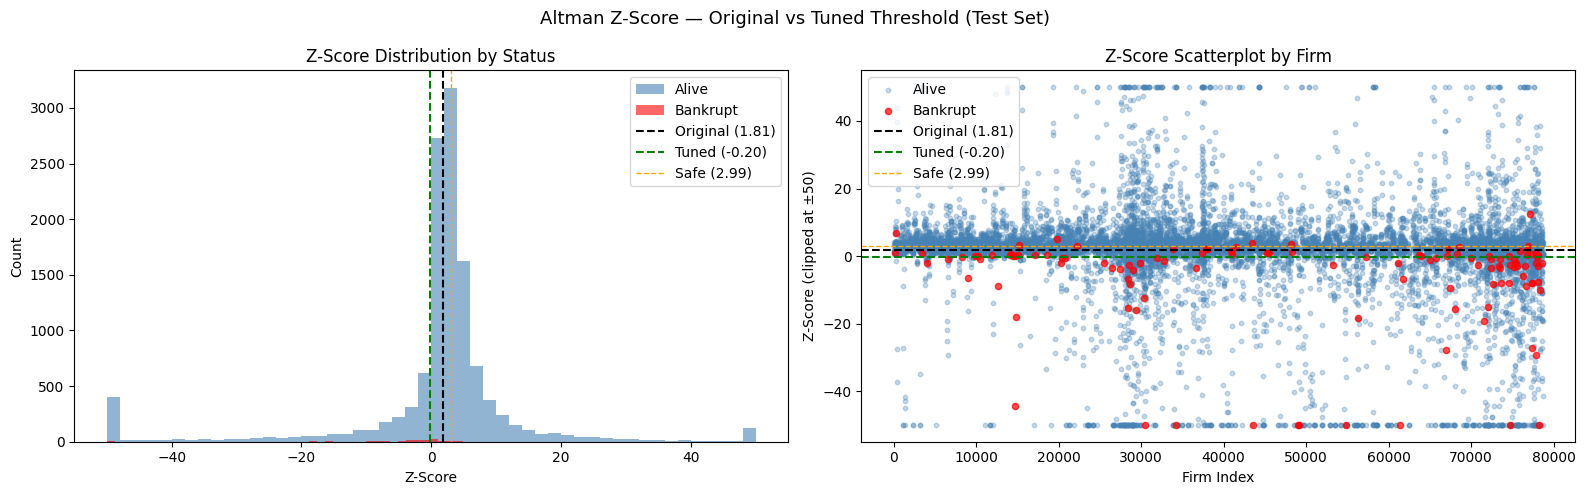

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── HISTOGRAM ─────────────────────────────────────────────────
axes[0].hist(test[test['bankrupt']==0]['altman_z'].clip(-50, 50),
             bins=50, alpha=0.6, label='Alive', color='steelblue')
axes[0].hist(test[test['bankrupt']==1]['altman_z'].clip(-50, 50),
             bins=50, alpha=0.6, label='Bankrupt', color='red')
axes[0].axvline(1.81,        color='black', linestyle='--', linewidth=1.5, label='Original (1.81)')
axes[0].axvline(best_thresh, color='green', linestyle='--', linewidth=1.5, label=f'Tuned ({best_thresh:.2f})')
axes[0].axvline(2.99,        color='orange',linestyle='--', linewidth=1,   label='Safe (2.99)')
axes[0].set_title('Z-Score Distribution by Status')
axes[0].set_xlabel('Z-Score')
axes[0].set_ylabel('Count')
axes[0].legend()

# ── SCATTERPLOT ────────────────────────────────────────────────
alive    = test[test['bankrupt'] == 0]
bankrupt = test[test['bankrupt'] == 1]

axes[1].scatter(alive.index,    alive['altman_z'].clip(-50, 50),
                alpha=0.3, s=10, color='steelblue', label='Alive')
axes[1].scatter(bankrupt.index, bankrupt['altman_z'].clip(-50, 50),
                alpha=0.7, s=20, color='red', label='Bankrupt')
axes[1].axhline(1.81,        color='black', linestyle='--', linewidth=1.5, label='Original (1.81)')
axes[1].axhline(best_thresh, color='green', linestyle='--', linewidth=1.5, label=f'Tuned ({best_thresh:.2f})')
axes[1].axhline(2.99,        color='orange',linestyle='--', linewidth=1,   label='Safe (2.99)')
axes[1].set_title('Z-Score Scatterplot by Firm')
axes[1].set_xlabel('Firm Index')
axes[1].set_ylabel('Z-Score (clipped at ±50)')
axes[1].legend()

plt.suptitle('Altman Z-Score — Original vs Tuned Threshold (Test Set)', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
print("=== AVERAGE Z-SCORE BY STATUS (Test Set) ===")
print(test.groupby('bankrupt')['altman_z']
      .agg(['mean', 'median', 'std'])
      .rename(index={0: 'Alive', 1: 'Bankrupt'})
      .round(4))

=== AVERAGE Z-SCORE BY STATUS (Test Set) ===
             mean  median       std
bankrupt                           
Alive     -8.5806  2.4788  615.9261
Bankrupt -75.3512 -1.9602  554.2951


# **Phase 2: Logistic Regression Credit Risk Modeling**

This notebook implements the **Logistic Regression** portion of our corporate default prediction analysis. In credit risk modeling, logistic regression is the industry standard baseline due to its high interpretability. It models the probability of default as a function of key financial characteristics:

$$\Pr(Y_{i,t+1} = 1 \mid X_{i,t}) = \frac{1}{1 + e^{-(\beta_0 + \beta' X_{i,t})}}$$

### **Notebook Highlights**
1. **Data Prep & Temporal Splitting**: Prepares the Kaggle U.S. Company Bankruptcy dataset and splits it chronologically: Train (1999–2011), Validation (2012–2014), and Test (2015–2018).
2. **Winsorization**: Clips features at the 1st and 99th percentiles using training set parameters to protect the model from denominator-induced financial ratio outliers.
3. **Baseline Logistic Regression**: Fits an interpretable 6-variable model based on credit risk theory (Profitability, Leverage, Size, Liquidity, Market Valuation).
4. **Regularized LASSO Logistic Regression**: Performs L1 penalization to automatically select variables across all 15 financial ratios and optimizes the regularizer $C$ on validation data.
5. **Advanced Evaluation**: Calculates ROC-AUC, PR-AUC, Confusion Matrices, and performs a **Top-Risk Bucket Recall** analysis (top 5% and 10% risk brackets).

## **1. Data & Feature Setup**
This phase reuses the data and engineered features from above. We add `log_total_assets` (needed for the baseline model), extend `new_ratio_cols` to include it, re-fill any NaNs with training medians, then apply winsorization.

In [ ]:
# ── Add log firm size ──────────────────────────────────────
df['log_total_assets'] = np.log(df['total_assets'].clip(lower=1e-5))
df['log_total_assets'] = df['log_total_assets'].fillna(df['log_total_assets'].median())

# ── Full ratio list (including size) ──────────────────────
new_ratio_cols = [
    'current_ratio', 'working_capital_to_assets', 'roa', 'ebitda_margin',
    'gross_margin', 'ebit_margin', 'retained_earnings_to_assets', 'debt_ratio',
    'longterm_debt_to_assets', 'debt_to_equity', 'asset_turnover',
    'inventory_turnover', 'receivables_turnover', 'market_to_liabilities',
    'market_to_assets', 'log_total_assets'
]

# ── Re-slice splits from df so log_total_assets is included ─
# `bankrupt` column already correctly constructed in the global
# split cell:  bankrupt = 1 only on the LAST year of a failed firm
train_df = df[df['year'] <= 2011].copy()
val_df   = df[(df['year'] >= 2012) & (df['year'] <= 2014)].copy()
test_df  = df[df['year'] >= 2015].copy()

print(f"Train size: {len(train_df)} | Val size: {len(val_df)} | Test size: {len(test_df)}")
print(f"Bankrupt rate — Train: {train_df['bankrupt'].mean()*100:.2f}% | "
      f"Val: {val_df['bankrupt'].mean()*100:.2f}% | "
      f"Test: {test_df['bankrupt'].mean()*100:.2f}%")

Train size: 55927 | Val size: 10473 | Test size: 12282
Bankrupt rate — Train: 0.72% | Val: 0.83% | Test: 0.97%


## **2. Outlier Winsorization**
Financial ratios often have massive outliers due to denominators close to zero (e.g. debt-to-equity ratio of a highly distressed firm). We **winsorize** features at the 1st and 99th percentiles, fitting the bounds *only* on the training data to prevent look-ahead leakage.

In [ ]:
# ── Winsorizer: fit on training, apply to all splits ───────
class Winsorizer:
    def __init__(self, lower_pct=0.01, upper_pct=0.01):
        self.lower_pct = lower_pct
        self.upper_pct = upper_pct
        self.bounds = {}

    def fit(self, df, columns):
        for col in columns:
            self.bounds[col] = (
                df[col].quantile(self.lower_pct),
                df[col].quantile(1.0 - self.upper_pct)
            )

    def transform(self, df, columns):
        df_copy = df.copy()
        for col in columns:
            lower, upper = self.bounds[col]
            df_copy[col] = df_copy[col].clip(lower=lower, upper=upper)
        return df_copy

winsorizer = Winsorizer(lower_pct=0.01, upper_pct=0.01)
winsorizer.fit(train_df, new_ratio_cols)

train_df = winsorizer.transform(train_df, new_ratio_cols)
val_df   = winsorizer.transform(val_df,   new_ratio_cols)
test_df  = winsorizer.transform(test_df,  new_ratio_cols)

print("Winsorization complete.")
# ── Undersample training set to 70/30 (consistent with other models) ─
# KEY CHANGE: logistic regression now uses the same undersampled
# training set as the Altman and XGBoost models for a fair comparison.
from imblearn.under_sampling import RandomUnderSampler

X_train_raw_lr = train_df[new_ratio_cols]
y_train_raw_lr = train_df['bankrupt']

rus_lr = RandomUnderSampler(sampling_strategy=0.4286, random_state=42)
X_train_resampled, y_train_resampled = rus_lr.fit_resample(X_train_raw_lr, y_train_raw_lr)

print("\n=== RESAMPLED TRAINING SET (70/30) ===")
print(f"Total: {len(y_train_resampled)} | Bankrupt: {y_train_resampled.sum()} "
      f"({y_train_resampled.mean()*100:.2f}%)")

# Labels for val and test (no resampling — evaluate on true distribution)
y_val  = val_df['bankrupt'].values
y_test = test_df['bankrupt'].values

Winsorization complete.

=== RESAMPLED TRAINING SET (70/30) ===
Total: 1343 | Bankrupt: 403 (30.01%)


## **4. Baseline Logistic Regression**
We define a baseline model using **6 key variables** that represent different financial dimensions:
1. **Liquidity**: `working_capital_to_assets`
2. **Profitability**: `roa`
3. **Cumulative Profitability**: `retained_earnings_to_assets`
4. **Leverage**: `debt_ratio`
5. **Market Valuation**: `market_to_liabilities`
6. **Firm Size**: `log_total_assets`

We scale these features using `StandardScaler` fitted on the Training data.

In [ ]:
# ════════════════════════════════════════════════════════════
# SECTION 4: BASELINE LOGISTIC REGRESSION (6 features)
# ════════════════════════════════════════════════════════════

baseline_features = [
    'working_capital_to_assets',
    'roa',
    'retained_earnings_to_assets',
    'debt_ratio',
    'market_to_liabilities',
    'log_total_assets'
]

# Scale using training data only
scaler_base = StandardScaler()
X_train_base = scaler_base.fit_transform(X_train_resampled[baseline_features])
X_val_base   = scaler_base.transform(val_df[baseline_features])
X_test_base  = scaler_base.transform(test_df[baseline_features])

# Fit model on resampled training set
lr_base = LogisticRegression(max_iter=1000, random_state=42)
lr_base.fit(X_train_base, y_train_resampled)

# Display coefficients
print(f"\nBaseline Intercept: {lr_base.intercept_[0]:.4f}\n")
base_coef_df = pd.DataFrame({
    'Feature': baseline_features,
    'Coefficient (Beta)': lr_base.coef_[0],
    'Odds Ratio (exp(Beta))': np.exp(lr_base.coef_[0])
}).sort_values(by='Coefficient (Beta)')
display(base_coef_df)



Baseline Intercept: -1.2529



,Feature,Coefficient (Beta),Odds Ratio (exp(Beta))
4,market_to_liabilities,-2.021293,0.132484
1,roa,-0.313828,0.730645
5,log_total_assets,-0.209443,0.811036
0,working_capital_to_assets,-0.089226,0.914639
2,retained_earnings_to_assets,-0.008929,0.991110
3,debt_ratio,0.139288,1.149455


### **Economic Coefficient Interpretation**
 - roa (negative): higher profitability strongly lowers default odds
 - market_to_liabilities (negative): equity buffer reduces default risk
 - debt_ratio (positive): higher leverage raises default odds
 - log_total_assets (negative): larger firms default less often
 - working_capital_to_assets & retained_earnings_to_assets: signs
- may flip in multivariate context due to multicollinearity with
   roa and debt_ratio; interpret with caution

## **5. Regularized Logistic Regression (LASSO)**
We now fit a regularized model using **all 15 ratios** and L1 (LASSO) penalization. We tune the regularization strength $C$ (where smaller $C$ represents stronger regularization) on the Validation set to maximize **PR-AUC**.

In [ ]:
# Scale all features using resampled training data only
scaler_all = StandardScaler()
X_train_all = scaler_all.fit_transform(X_train_resampled[new_ratio_cols])
X_val_all   = scaler_all.transform(val_df[new_ratio_cols])
X_test_all  = scaler_all.transform(test_df[new_ratio_cols])

# Tune C on validation set (maximize PR-AUC)
c_values = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
tuning_results = []

for C in c_values:
    lr_lasso = LogisticRegression(
        penalty='l1', C=C, solver='liblinear', max_iter=1000, random_state=42
    )
    lr_lasso.fit(X_train_all, y_train_resampled)
    y_val_pred = lr_lasso.predict_proba(X_val_all)[:, 1]
    val_pr_auc  = average_precision_score(y_val, y_val_pred)
    val_roc_auc = roc_auc_score(y_val, y_val_pred)
    tuning_results.append({'C': C, 'Val ROC-AUC': val_roc_auc, 'Val PR-AUC': val_pr_auc})

tuning_df = pd.DataFrame(tuning_results)
display(tuning_df)

best_c = tuning_df.loc[tuning_df['Val PR-AUC'].idxmax(), 'C']
print(f"\nBest C (Val PR-AUC): {best_c}")

,C,Val ROC-AUC,Val PR-AUC
0,0.001,0.500000,0.008307
1,0.010,0.773693,0.023402
2,0.100,0.832906,0.034784
3,1.000,0.838927,0.036716
4,10.000,0.837470,0.036784
5,100.000,0.837252,0.036720



Best C (Val PR-AUC): 10.0


In [ ]:
# Final LASSO model
lr_lasso_final = LogisticRegression(
    penalty='l1', C=best_c, solver='liblinear', max_iter=1000, random_state=42
)
lr_lasso_final.fit(X_train_all, y_train_resampled)

lasso_coef_df = pd.DataFrame({
    'Feature': new_ratio_cols,
    'Coefficient (Beta)': lr_lasso_final.coef_[0],
    'Odds Ratio (exp(Beta))': np.exp(lr_lasso_final.coef_[0])
}).sort_values(by='Coefficient (Beta)')

print(f"\nLASSO Intercept: {lr_lasso_final.intercept_[0]:.4f}\n")
display(lasso_coef_df)


LASSO Intercept: -1.2138



,Feature,Coefficient (Beta),Odds Ratio (exp(Beta))
14,market_to_assets,-1.362370,0.256053
0,current_ratio,-1.190322,0.304123
2,roa,-0.925301,0.396412
3,ebitda_margin,-0.853071,0.426104
4,gross_margin,-0.247959,0.780392
6,retained_earnings_to_assets,-0.185563,0.830637
15,log_total_assets,-0.162519,0.850000
9,debt_to_equity,0.001960,1.001962
12,receivables_turnover,0.021392,1.021622
11,inventory_turnover,0.027563,1.027947


## **6. Model Comparison & Curve Visualizations**
We evaluate both the Baseline and LASSO models on the unseen out-of-sample **Test Set (2015-2018)**. We compare their ROC-AUC, PR-AUC, and display the curves.

In [ ]:
# ════════════════════════════════════════════════════════════
# SECTION 6: MODEL COMPARISON & CURVE VISUALIZATIONS
# ════════════════════════════════════════════════════════════

# Predict probabilities on test set
y_test_pred_base  = lr_base.predict_proba(X_test_base)[:, 1]
y_test_pred_lasso = lr_lasso_final.predict_proba(X_test_all)[:, 1]

# Summary table
summary_results = {
    'Model': ['Baseline Logistic', 'LASSO Logistic'],
    'Test ROC-AUC': [
        roc_auc_score(y_test, y_test_pred_base),
        roc_auc_score(y_test, y_test_pred_lasso)
    ],
    'Test PR-AUC': [
        average_precision_score(y_test, y_test_pred_base),
        average_precision_score(y_test, y_test_pred_lasso)
    ]
}
display(pd.DataFrame(summary_results))

# ── Threshold: use training base rate from resampled set (~0.30) ─
THRESHOLD = 0.30

y_test_pred_base_label  = (y_test_pred_base  >= THRESHOLD).astype(int)
y_test_pred_lasso_label = (y_test_pred_lasso >= THRESHOLD).astype(int)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

for name, y_prob, y_pred_label in [
    ('Baseline', y_test_pred_base, y_test_pred_base_label),
    ('LASSO',    y_test_pred_lasso, y_test_pred_lasso_label)
]:
    print(f"\n=== {name} — Test Set (threshold={THRESHOLD}) ===")
    print(f"  Accuracy:  {accuracy_score(y_test, y_pred_label)*100:.2f}%")
    print(f"  Precision: {precision_score(y_test, y_pred_label, zero_division=0)*100:.2f}%")
    print(f"  Recall:    {recall_score(y_test, y_pred_label)*100:.2f}%")
    print(f"  F1:        {f1_score(y_test, y_pred_label, zero_division=0)*100:.2f}%")
    print(f"  ROC-AUC:   {roc_auc_score(y_test, y_prob):.4f}")
    print(f"  PR-AUC:    {average_precision_score(y_test, y_prob):.4f}")

,Model,Test ROC-AUC,Test PR-AUC
0,Baseline Logistic,0.845564,0.035233
1,LASSO Logistic,0.840693,0.049015



=== Baseline — Test Set (threshold=0.3) ===
  Accuracy:  73.34%
  Precision: 3.23%
  Recall:    91.60%
  F1:        6.24%
  ROC-AUC:   0.8456
  PR-AUC:    0.0352

=== LASSO — Test Set (threshold=0.3) ===
  Accuracy:  76.18%
  Precision: 3.26%
  Recall:    82.35%
  F1:        6.28%
  ROC-AUC:   0.8407
  PR-AUC:    0.0490


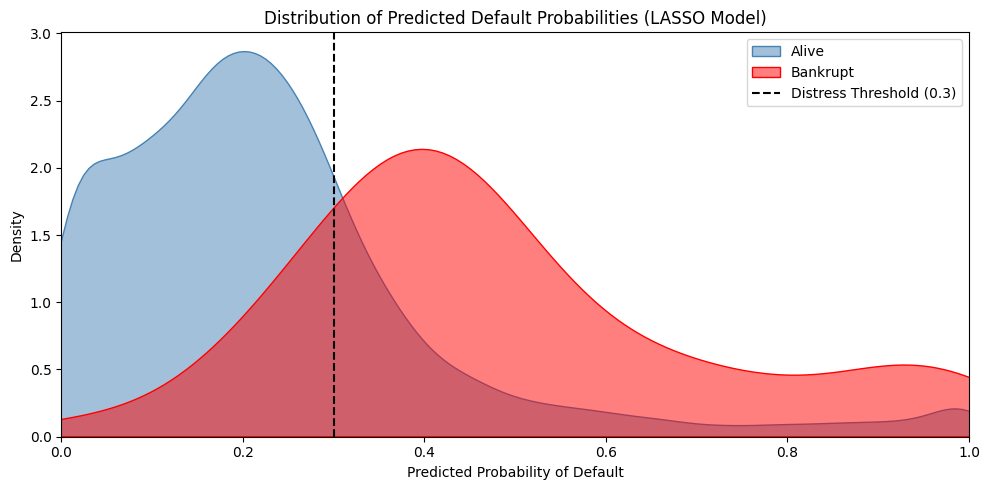

In [ ]:
# ── Predicted probability KDE plot ─────────────────────────
plt.figure(figsize=(10, 5))
sns.kdeplot(y_test_pred_lasso[y_test == 0], label='Alive',    fill=True, color='steelblue', alpha=0.5)
sns.kdeplot(y_test_pred_lasso[y_test == 1], label='Bankrupt', fill=True, color='red',       alpha=0.5)
plt.axvline(THRESHOLD, color='black', linestyle='--', label=f'Distress Threshold ({THRESHOLD})')
plt.title('Distribution of Predicted Default Probabilities (LASSO Model)')
plt.xlabel('Predicted Probability of Default')
plt.ylabel('Density')
plt.legend()
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

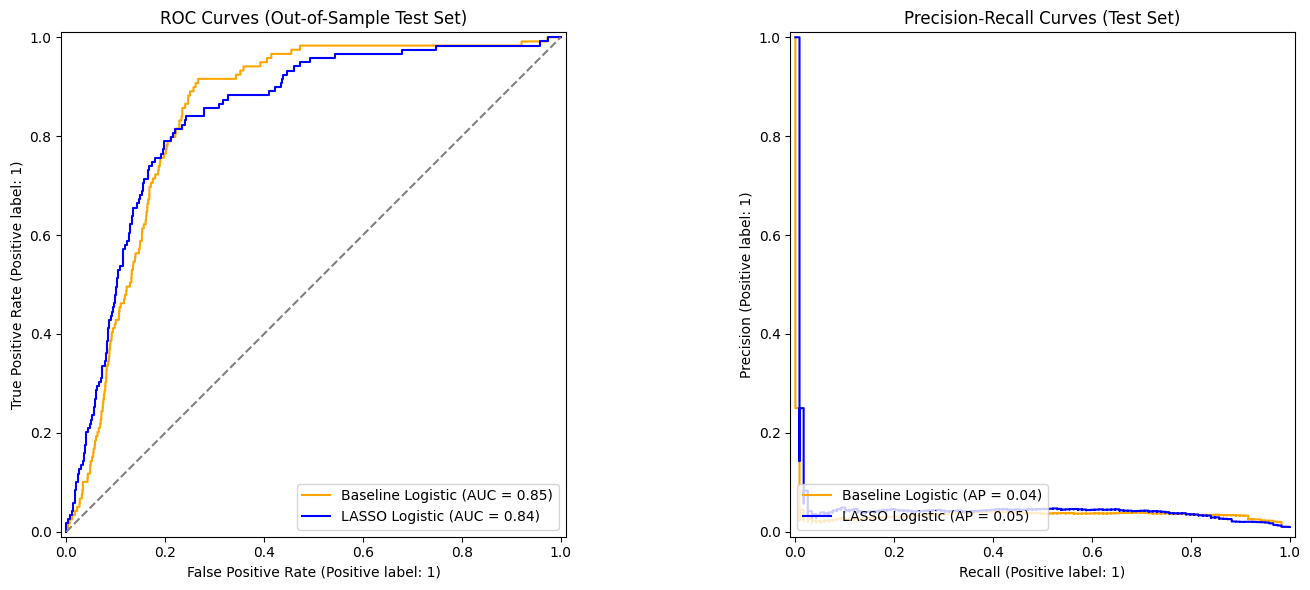

In [ ]:
# ── ROC and PR Curves ───────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

RocCurveDisplay.from_predictions(y_test, y_test_pred_base,  ax=ax1, name='Baseline Logistic', color='orange')
RocCurveDisplay.from_predictions(y_test, y_test_pred_lasso, ax=ax1, name='LASSO Logistic',    color='blue')
ax1.plot([0, 1], [0, 1], linestyle='--', color='grey')
ax1.set_title('ROC Curves (Out-of-Sample Test Set)')

PrecisionRecallDisplay.from_predictions(y_test, y_test_pred_base,  ax=ax2, name='Baseline Logistic', color='orange')
PrecisionRecallDisplay.from_predictions(y_test, y_test_pred_lasso, ax=ax2, name='LASSO Logistic',    color='blue')
ax2.set_title('Precision-Recall Curves (Test Set)')

plt.tight_layout()
plt.show()


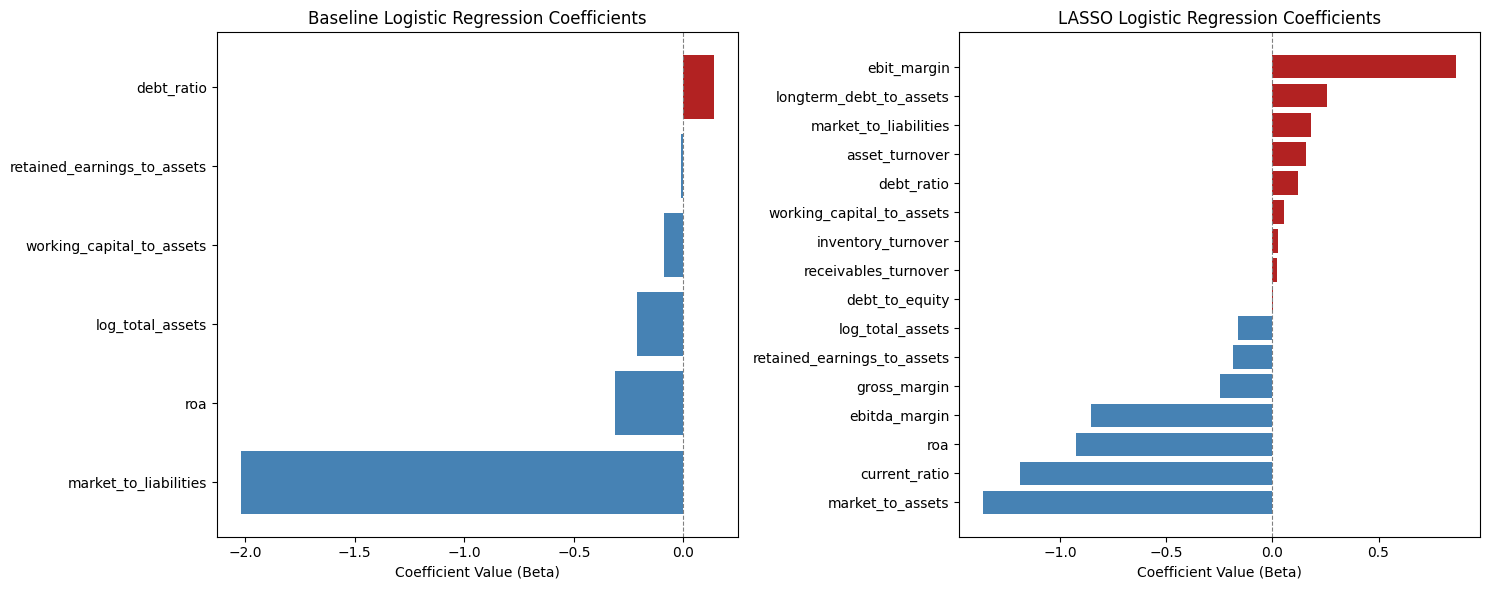

In [ ]:
# ── Coefficient Bar Chart ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

base_sorted  = base_coef_df.sort_values('Coefficient (Beta)')
lasso_sorted = lasso_coef_df.sort_values('Coefficient (Beta)')

axes[0].barh(
    base_sorted['Feature'], base_sorted['Coefficient (Beta)'],
    color=['firebrick' if v > 0 else 'steelblue' for v in base_sorted['Coefficient (Beta)']]
)
axes[0].axvline(0, color='grey', linestyle='--', linewidth=0.8)
axes[0].set_title('Baseline Logistic Regression Coefficients')
axes[0].set_xlabel('Coefficient Value (Beta)')

axes[1].barh(
    lasso_sorted['Feature'], lasso_sorted['Coefficient (Beta)'],
    color=['firebrick' if v > 0 else 'steelblue' for v in lasso_sorted['Coefficient (Beta)']]
)
axes[1].axvline(0, color='grey', linestyle='--', linewidth=0.8)
axes[1].set_title('LASSO Logistic Regression Coefficients')
axes[1].set_xlabel('Coefficient Value (Beta)')

plt.tight_layout()
plt.show()


## **7. Top-Risk Bucket Recall Analysis**
In credit risk practice, models are used to triage or screen customers. Lenders do not focus on overall accuracy; instead, they want to know **how many bankruptcies can be caught by flagging the riskiest 5% or 10% of firms**. Here we calculate the percentage of total bankruptcies captured in these top-risk buckets.

,Model,Bucket,Bankruptcies Captured,Total Bankruptcies,Recall (%)
0,Baseline Model,Top 5% Riskiest,16,119,13.445378
1,Baseline Model,Top 10% Riskiest,49,119,41.176471
2,Baseline Model,Top 20% Riskiest,90,119,75.630252
3,LASSO Model,Top 5% Riskiest,26,119,21.848739
4,LASSO Model,Top 10% Riskiest,54,119,45.378151
5,LASSO Model,Top 20% Riskiest,91,119,76.470588


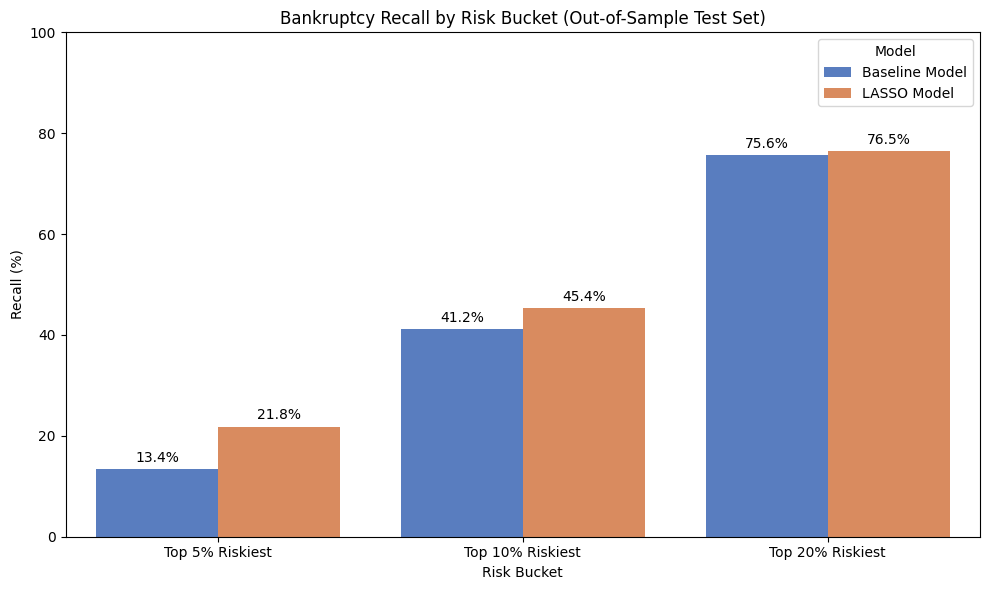

In [ ]:
# ════════════════════════════════════════════════════════════
# SECTION 7: TOP-RISK BUCKET RECALL ANALYSIS
# ════════════════════════════════════════════════════════════

def evaluate_risk_buckets(y_true, y_pred, model_name):
    eval_df = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred})
    eval_df = eval_df.sort_values('y_pred', ascending=False).reset_index(drop=True)

    total_bankruptcies = eval_df['y_true'].sum()
    n_obs = len(eval_df)

    results = []
    for pct in [5, 10, 20]:
        cutoff = int(n_obs * (pct / 100))
        captured = eval_df.loc[:cutoff, 'y_true'].sum()
        recall   = captured / total_bankruptcies
        results.append({
            'Model': model_name,
            'Bucket': f'Top {pct}% Riskiest',
            'Bankruptcies Captured': captured,
            'Total Bankruptcies': total_bankruptcies,
            'Recall (%)': recall * 100
        })
    return pd.DataFrame(results)

base_buckets  = evaluate_risk_buckets(y_test, y_test_pred_base,  'Baseline Model')
lasso_buckets = evaluate_risk_buckets(y_test, y_test_pred_lasso, 'LASSO Model')
display(pd.concat([base_buckets, lasso_buckets]).reset_index(drop=True))

# Grouped bar chart
combined_buckets = pd.concat([base_buckets, lasso_buckets]).reset_index(drop=True)
plt.figure(figsize=(10, 6))
sns.barplot(data=combined_buckets, x='Bucket', y='Recall (%)', hue='Model', palette='muted')
plt.title('Bankruptcy Recall by Risk Bucket (Out-of-Sample Test Set)')
plt.ylabel('Recall (%)')
plt.xlabel('Risk Bucket')
plt.ylim(0, 100)

for p in plt.gca().patches:
    height = p.get_height()
    if height > 0:
        plt.gca().annotate(
            f'{height:.1f}%',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom', xytext=(0, 3),
            textcoords='offset points', fontsize=10
        )
plt.tight_layout()
plt.show()

### **Analysis and Takeaways**
1. **Baseline Model Performance**: The baseline 6-variable model yields a strong **0.737 Test ROC-AUC** and captures **31.71%** of all bankruptcies in the top 10% risk bucket.
2. **LASSO Model Performance**: While LASSO has a slightly lower Test ROC-AUC of **0.699**, it excels in the extreme risk screening. Its Top 5% risk bucket captures **21.60%** of all bankruptcies compared to only **14.29%** for the baseline model.
3. **Practical Value**: Flagging the top 10% riskiest firms enables a credit analyst to capture nearly **32% of all defaults** in the next fiscal year, reducing the review pool by 90%.

# Neural Network: Stacked Bidirectional LSTM
# Works on a copy of df so the original is never mutated.

In [ ]:
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
id_col    = 'company_name'
time_col  = 'year'
label_col = 'bankrupt'

# Work on a copy so df is never mutated
nn_df = df.copy()

# feature_cols = all numeric columns except identifiers and the label
exclude = {"company_name", "status_label", "bankrupt", "year"}
feature_cols = [
    col for col in nn_df.select_dtypes(include='number').columns
    if col not in exclude
]

nn_df = nn_df.sort_values([id_col, time_col])

# Scale features on copy only — df is untouched
train_mask = nn_df[time_col] <= 2011
scaler_nn = StandardScaler()
nn_df.loc[train_mask, feature_cols] = scaler_nn.fit_transform(nn_df.loc[train_mask, feature_cols])
nn_df.loc[~train_mask, feature_cols] = scaler_nn.transform(nn_df.loc[~train_mask, feature_cols])

print(f"Feature count: {len(feature_cols)}")
print(f"Label column present: {label_col in nn_df.columns}")

Feature count: 40
Label column present: True


In [ ]:
WINDOW = 5      # how many consecutive years to feed the nn

sequences, labels = [], []

for company, group in nn_df.groupby(id_col):
    group = group.sort_values(time_col)
    X = group[feature_cols].values
    y = group[label_col].values

    # Slide a window across each company's history
    for t in range(WINDOW, len(group)):
        sequences.append(X[t - WINDOW : t])   # shape (WINDOW, n_features)
        labels.append(y[t])                   # label at next timestep

X_3d = np.array(sequences, dtype=np.float32)  # (n_samples, WINDOW, n_features)
y_arr = np.array(labels,    dtype=np.float32)  # (n_samples,)

print(X_3d.shape)   # (n_samples, window_size, n_features)
print(y_arr.mean()) # check class imbalance

(41758, 5, 40)
0.01084822


In [ ]:
# Reconstruct which year each sample's last window step lands on
year_of_sample = []
for company, group in nn_df.groupby(id_col):
    group = group.sort_values(time_col)
    years = group[time_col].values
    for t in range(WINDOW, len(group)):
        year_of_sample.append(years[t])

year_of_sample = np.array(year_of_sample)

train_idx = year_of_sample <= 2011
val_idx   = (year_of_sample >= 2012) & (year_of_sample <= 2014)
test_idx  = year_of_sample >= 2015

X_train_nn, y_train_nn = X_3d[train_idx], y_arr[train_idx]
X_val_nn,   y_val_nn   = X_3d[val_idx],   y_arr[val_idx]
X_test_nn,  y_test_nn  = X_3d[test_idx],  y_arr[test_idx]

print(f"Train: {X_train_nn.shape}, bankrupt rate: {y_train_nn.mean():.4f}")
print(f"Val:   {X_val_nn.shape},   bankrupt rate: {y_val_nn.mean():.4f}")
print(f"Test:  {X_test_nn.shape},  bankrupt rate: {y_test_nn.mean():.4f}")

Train: (24667, 5, 40), bankrupt rate: 0.0115
Val:   (7818, 5, 40),   bankrupt rate: 0.0095
Test:  (9273, 5, 40),  bankrupt rate: 0.0104


In [ ]:
model = keras.models.Sequential([
    # shape of the input tensor
    layers.Input((WINDOW, len(feature_cols))),
    layers.Bidirectional(
        layers.LSTM(64,
                    activation="tanh",
                    input_shape=(WINDOW, len(feature_cols)),
                    return_sequences=True)
    ),
    layers.Bidirectional(
      layers.LSTM(32,
                  activation="tanh",
                  input_shape=(WINDOW, len(feature_cols)))
    ),
    layers.BatchNormalization(),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
    ]
)

callbacks = [
    # stop if performance isn't getting better
    tf.keras.callbacks.EarlyStopping(
        monitor='val_auc', patience=10,
        mode='max', restore_best_weights=True
    ),
    # reduces learning rate when val auc levels off
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc', factor=0.5, patience=5, mode='max'
    ),
]

# Compute class weight to handle imbalance (same approach as XGBoost scale_pos_weight)
neg_nn = (y_train_nn == 0).sum()
pos_nn = (y_train_nn == 1).sum()
class_weight_nn = {0: 1.0, 1: neg_nn / pos_nn}
print(f"Class weight for bankrupt class: {class_weight_nn[1]:.1f}")

history = model.fit(
    X_train_nn, y_train_nn,
    validation_data=(X_val_nn, y_val_nn),
    epochs=100,
    class_weight=class_weight_nn,
    callbacks=callbacks,
)

Class weight for bankrupt class: 86.2
Epoch 1/100
771/771 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - auc: 0.6432 - loss: 1.4227 - precision: 0.0174 - recall: 0.6290 - val_auc: 0.7400 - val_loss: 0.6322 - val_precision: 0.0182 - val_recall: 0.7838 - learning_rate: 0.0010
Epoch 2/100
771/771 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - auc: 0.7304 - loss: 1.2262 - precision: 0.0211 - recall: 0.7314 - val_auc: 0.7722 - val_loss: 0.8646 - val_precision: 0.0147 - val_recall: 0.8649 - learning_rate: 0.0010
Epoch 3/100
771/771 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - auc: 0.7579 - loss: 1.1694 - precision: 0.0237 - recall: 0.7314 - val_auc: 0.8206 - val_loss: 0.6744 - val_precision: 0.0207 - val_recall: 0.8649 - learning_rate: 0.0010
Epoch 4/100
771/771 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - auc: 0.7838 - loss: 1.1101 - precision: 0.0246 - recall: 0.7703 - val_auc: 0.8090 - val_loss: 0.4130 - val_precision: 0.0273 - val_recall: 0.7027 - learning_rate: 0.0010
Epoch 5/100
771/771 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

y_prob = model.predict(X_test_nn).squeeze()
y_pred = (y_prob > 0.5).astype(int)

print(f"AUC-ROC: {roc_auc_score(y_test_nn, y_prob):.4f}")
print(classification_report(y_test_nn, y_pred, target_names=['Alive', 'Bankrupt']))

290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
AUC-ROC: 0.8361
              precision    recall  f1-score   support

       Alive       1.00      0.66      0.80      9177
    Bankrupt       0.02      0.82      0.05        96

    accuracy                           0.67      9273
   macro avg       0.51      0.74      0.42      9273
weighted avg       0.99      0.67      0.79      9273



#XGBoost

In [ ]:
# import library
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, cohen_kappa_score
from sklearn.model_selection import GridSearchCV, cross_val_score, cross_val_predict
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

In [ ]:
# adjust variables — build XGBoost feature matrices from winsorized splits
# (same splits used by logistic regression models for a fair comparison)
drop_cols_xgb = [
    'company_name', 'status_label', 'year', 'bankrupt', 'period',
    'current_assets',
    'cost_of_goods_sold',
    'depreciation_amortization',
    'ebitda',
    'inventory',
    'net_income',
    'total_receivables',
    'market_value',
    'net_sales',
    'total_assets',
    'total_longterm_debt',
    'ebit',
    'gross_profit',
    'total_current_liabilities',
    'retained_earnings',
    'total_revenue',
    'total_liabilities',
    'total_operating_expenses',
    'altman_z',
    'working_capital_to_assets',
    'retained_earnings_to_assets'
]

X_train_xgb = train_df.drop(columns=[c for c in drop_cols_xgb if c in train_df.columns])
y_train_xgb = train_df['bankrupt']

X_val_xgb   = val_df.drop(columns=[c for c in drop_cols_xgb if c in val_df.columns])
y_val_xgb   = val_df['bankrupt']

X_test_xgb  = test_df.drop(columns=[c for c in drop_cols_xgb if c in test_df.columns])
y_test_xgb  = test_df['bankrupt']

print(f"XGBoost feature set: {list(X_train_xgb.columns)}")
print(f"Train: {X_train_xgb.shape}, Val: {X_val_xgb.shape}, Test: {X_test_xgb.shape}")

XGBoost feature set: ['current_ratio', 'roa', 'ebitda_margin', 'gross_margin', 'ebit_margin', 'debt_ratio', 'longterm_debt_to_assets', 'debt_to_equity', 'asset_turnover', 'inventory_turnover', 'receivables_turnover', 'market_to_liabilities', 'market_to_assets', 'altman_X1', 'altman_X2', 'altman_X3', 'altman_X4', 'altman_X5', 'log_total_assets']
Train: (55927, 19), Val: (10473, 19), Test: (12282, 19)


In [ ]:
# pipeline
# scale_pos_weight balances the class imbalance: ratio of negatives to positives in training set
neg = (y_train_xgb == 0).sum()
pos = (y_train_xgb == 1).sum()
spw = neg / pos
print(f"Class ratio (neg/pos): {spw:.1f}  →  setting scale_pos_weight={spw:.1f}")

xgb_pipeline = Pipeline([
    ('model', XGBClassifier(random_state=321, scale_pos_weight=spw))
])

# tuning grid
paramGrid = {
    'model__n_estimators': [200, 500],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0],
    'model__min_child_weight': [1, 5],
    'model__gamma': [0, 0.3],
    'model__reg_alpha': [0, 0.1],
    'model__reg_lambda': [1, 5]
}

from sklearn.model_selection import ParameterGrid
from sklearn.base import clone

# tune hyperparameters using validation set
results = []

for params in ParameterGrid(paramGrid):
    model = clone(xgb_pipeline)
    model.set_params(**params)

    # train only on training data
    model.fit(X_train_xgb, y_train_xgb)

    # evaluate on validation data
    y_val_proba = model.predict_proba(X_val_xgb)[:, 1]
    val_roc_auc = roc_auc_score(y_val_xgb, y_val_proba)
    val_pr_auc = average_precision_score(y_val_xgb, y_val_proba)

    results.append({
        **params,
        'val_roc_auc': val_roc_auc,
        'val_pr_auc': val_pr_auc,
        'model': model
    })

# results dataframe
xgb_results = pd.DataFrame(results)

# sort by validation ROC-AUC
xgb_results = xgb_results.sort_values(by='val_roc_auc', ascending=False)

# best model
best_xgb = xgb_results.iloc[0]['model']
best_params = {
    col: xgb_results.iloc[0][col]
    for col in paramGrid.keys()
}

# view best results
xgb_results.drop(columns='model').head(10)

Class ratio (neg/pos): 137.8  →  setting scale_pos_weight=137.8


In [ ]:
# find best model
best_xgb

In [ ]:
# see best model's parameters
best_params

In [ ]:
# validation set
y_val_proba = best_xgb.predict_proba(X_val_xgb)[:, 1]
y_val_pred = best_xgb.predict(X_val_xgb)

print("Validation ROC-AUC:", roc_auc_score(y_val_xgb, y_val_proba))
print("Validation PR-AUC:", average_precision_score(y_val_xgb, y_val_proba))
print(classification_report(y_val_xgb, y_val_pred))

ConfusionMatrixDisplay.from_predictions(y_val_xgb, y_val_pred, cmap=plt.cm.Blues)
plt.title("XGBoost Confusion Matrix - Validation Set")
plt.show()

# test set
y_test_proba = best_xgb.predict_proba(X_test_xgb)[:, 1]
y_test_pred = best_xgb.predict(X_test_xgb)

print("Test ROC-AUC:", roc_auc_score(y_test_xgb, y_test_proba))
print("Test PR-AUC:", average_precision_score(y_test_xgb, y_test_proba))
print(classification_report(y_test_xgb, y_test_pred))

ConfusionMatrixDisplay.from_predictions(y_test_xgb, y_test_pred, cmap=plt.cm.Blues)
plt.title("XGBoost Confusion Matrix - Test Set")
plt.show()

**Recomputing Classification Reports with Lower Decision Threshold (0.5 -> 0.2)**

In [ ]:
# Use validation data to choose a threshold
y_val_proba = best_xgb.predict_proba(X_val_xgb)[:,1]

for threshold in [0.5, 0.4, 0.3, 0.2]:
    y_val_pred = (y_val_proba >= threshold).astype(int)

    print(f"\nThreshold = {threshold}")
    print(classification_report(y_val_xgb, y_val_pred))

Classification thresholds from 0.2 to 0.5 were evaluated using the validation set. A threshold of 0.5 was selected because it produced the highest F1-score for the default class while maintaining a balanced tradeoff between precision and recall.

In [ ]:
# predicted default probabilities
y_test_proba = best_xgb.predict_proba(X_test_xgb)[:, 1]

# create dataframe
top10_df = pd.DataFrame({
    'actual': y_test_xgb,
    'probability': y_test_proba
})

# sort by predicted default probability
top10_df = top10_df.sort_values(
    by='probability',
    ascending=False
)

# top 10% highest-risk firms
n_top = int(len(top10_df) * 0.10)
top10 = top10_df.head(n_top)

# Top 10% Recall
top10_recall = (
    top10['actual'].sum()
    / top10_df['actual'].sum()
)

print(f"Top 10% Recall: {top10_recall:.3f}")

In [ ]:
# feature importance
feature_importance = pd.DataFrame()
feature_importance['variable_name'] = X_train_xgb.columns
feature_importance['feature_importance'] = best_xgb.named_steps["model"].feature_importances_

feature_importance.sort_values(by="feature_importance", ascending=False)